# 자전거 대여 예측 [회귀]

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv(r'C:\Users\Admin\hipython\data\bike_train.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [28]:
print('=== 기본 정보 ===')
print(df.info())
print()
print('=== 기술 통계 ===')
display(df.describe())
print()
print('=== 결측치 ===')
print(df.isnull().sum())

=== 기본 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB
None

=== 기술 통계 ===


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000



=== 결측치 ===
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [29]:
# datetime → 파생 변수 추출
df['datetime'] = pd.to_datetime(df['datetime'])
df['year']     = df['datetime'].dt.year
df['month']    = df['datetime'].dt.month
df['hour']     = df['datetime'].dt.hour
df['dayofweek']= df['datetime'].dt.dayofweek

# 모델에 사용할 피처 선택 (datetime, casual, registered 제외)
feature_cols = ['season','holiday','workingday','weather',
                'temp','atemp','humidity','windspeed',
                'year','month','hour','dayofweek']

X = df[feature_cols].values
y = df['count'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('피처 목록:', feature_cols)

X shape: (10886, 12)
y shape: (10886,)
피처 목록: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape, '  X_test:', X_test.shape)

def evaluate(model_name, y_test, y_pred):
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f'[ {model_name} ]')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    print('-' * 35)
    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'R²': r2}

all_results = []   # 최종 비교용

X_train: (8708, 12)   X_test: (2178, 12)


# 단순회귀 모델

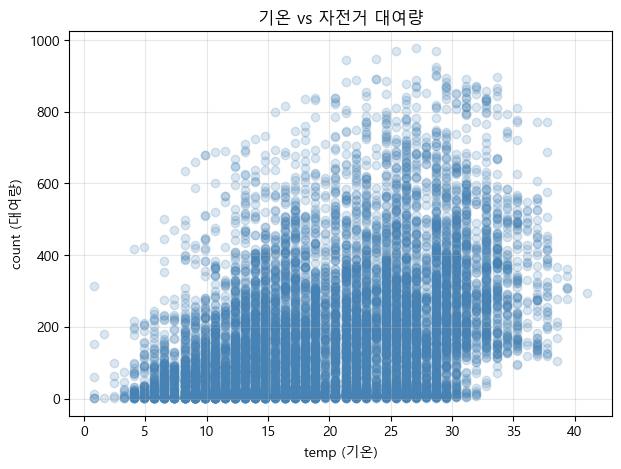

In [31]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 단순 회귀 모델
# 대표 단일 피처 1개만 사용: temp(기온) → count(대여량)

X_simple = df['temp'].values
y_simple  = df['count'].values

# 산점도 확인
plt.figure(figsize=(7, 5))
plt.scatter(X_simple, y_simple, alpha=0.2, color='steelblue')
plt.xlabel('temp (기온)')
plt.ylabel('count (대여량)')
plt.title('기온 vs 자전거 대여량')
plt.grid(alpha=0.3)
plt.show()

epoch   0  |  W: 45.0699  |  RMSE: 267.2287
epoch  40  |  W: 2094670626258242863366144.0000  |  RMSE: 12267395860422332472360960.0000
epoch  80  |  W: 122917079705958964081568558929052266568035074048.0000  |  RMSE: 719861373839776199989913038713259416731296727040.0000
epoch 120  |  W: 7212880294421230738534216774128718780843125032458164269452634475200512.0000  |  RMSE: 42242086539192293068399091746094017761542208495685248603382074761543680.0000
epoch 160  |  W: 423258039209078701573019116871645771471119940221279978101232133122787956292998007505784143872.0000  |  RMSE: 2478802086110789492988347420507050931799453210262297507752532832576711500142970618380111839232.0000

최종  W: -6697138715875448391608392060916561098647973351116419333299961202964937080175909937095809438840110228592492739035136.0000,  b: -288358828313288830435227621745026748262989162841565368521820028631519175580649537202669205051200280423178595991552.0000,  RMSE: 3922165648857287141517952345291832848970563199370514401451446

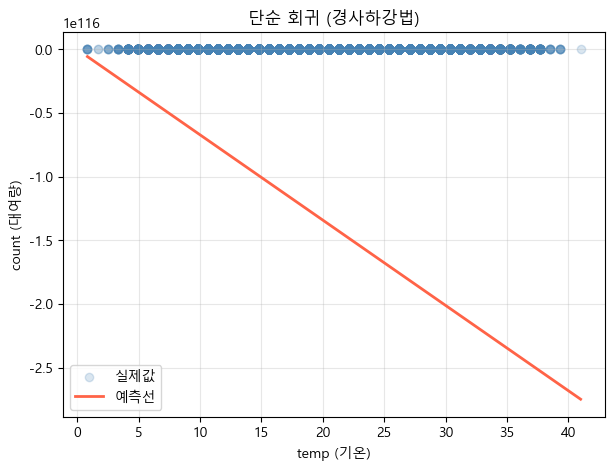

In [32]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 경사하강법으로 단순회귀 직접 학습 (y = W*x + b)

np.random.seed(42)
W = np.random.uniform(-1, 1)
b = np.random.uniform(-1, 1)
learning_rate = 0.01

for epoch in range(200):
    y_pred_s = W * X_simple + b
    error    = np.sqrt(np.mean((y_pred_s - y_simple) ** 2))   # RMSE

    if error < 1.0:
        break

    W -= learning_rate * ((y_pred_s - y_simple) * X_simple).mean()
    b -= learning_rate * ((y_pred_s - y_simple)).mean()

    if epoch % 40 == 0:
        print(f'epoch {epoch:3d}  |  W: {W:.4f}  |  RMSE: {error:.4f}')

print(f'\n최종  W: {W:.4f},  b: {b:.4f},  RMSE: {error:.4f}')

# 결과 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X_simple, y_simple, alpha=0.2, color='steelblue', label='실제값')
x_line = np.linspace(X_simple.min(), X_simple.max(), 100)
plt.plot(x_line, W * x_line + b, color='tomato', linewidth=2, label='예측선')
plt.xlabel('temp (기온)')
plt.ylabel('count (대여량)')
plt.title('단순 회귀 (경사하강법)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# LinearRegression 다중선형회귀

In [33]:
# LinearRegression (다중 선형 회귀)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

all_results.append(evaluate('LinearRegression', y_test, lr_pred))

# 피처 중요도 (계수)
coef_df = pd.Series(
    np.round(lr.coef_, 2),
    index=feature_cols
).sort_values(ascending=False)

print('\n피처별 계수:')
print(coef_df)

[ LinearRegression ]
  MSE  : 19952.5782
  RMSE : 141.2536
  R²   : 0.3955
-----------------------------------

피처별 계수:
year          82.69
month         10.18
hour           7.86
atemp          5.03
workingday     3.05
temp           1.15
dayofweek      0.66
windspeed      0.55
humidity      -2.03
weather       -5.19
holiday       -5.45
season        -8.16
dtype: float64


# 다항회귀 모델

In [34]:
# 다항 회귀 모델 (Polynomial Regression)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

degrees = [1, 2, 3]
poly_results = {}

print('=== 다항 회귀 비교 ===')
for d in degrees:
    if d == 1:
        model = LinearRegression()
    else:
        model = Pipeline([
            ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
            ('linear', LinearRegression())
        ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    poly_results[f'{d}차'] = {'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f'[{d}차 다항회귀]  RMSE: {rmse:.4f}  |  R²: {r2:.4f}')

print()
print(pd.DataFrame(poly_results).T.round(4))

=== 다항 회귀 비교 ===
[1차 다항회귀]  RMSE: 141.2536  |  R²: 0.3955
[2차 다항회귀]  RMSE: 120.3727  |  R²: 0.5610
[3차 다항회귀]  RMSE: 110.6068  |  R²: 0.6294

           MSE      RMSE      R²
1차  19952.5782  141.2536  0.3955
2차  14489.5818  120.3727  0.5610
3차  12233.8533  110.6068  0.6294


# 2차 다항 피처

In [35]:
# 2차 다항 피처 + StandardScaler (규제 모델 공통 전처리)
from sklearn.preprocessing import StandardScaler

poly2  = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()

X_train_poly   = poly2.fit_transform(X_train)
X_test_poly    = poly2.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled  = scaler.transform(X_test_poly)

print('2차 다항 피처 수:', X_train_poly.shape[1])
print('스케일링 완료 → shape:', X_train_scaled.shape)

2차 다항 피처 수: 90
스케일링 완료 → shape: (8708, 90)


# Ridge 회귀

In [36]:
# Ridge 회귀 (L2 규제)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

result_ridge = evaluate('Ridge (L2)', y_test, ridge_pred)
all_results.append(result_ridge)

[ Ridge (L2) ]
  MSE  : 14906.4179
  RMSE : 122.0918
  R²   : 0.5484
-----------------------------------


# Lasso 회귀

In [37]:
# Lasso 회귀 (L1 규제)
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

result_lasso = evaluate('Lasso (L1)', y_test, lasso_pred)
all_results.append(result_lasso)

# Lasso가 0으로 만든 피처 수 확인
zero_coef = np.sum(lasso.coef_ == 0)
print(f'  계수가 0인 피처 수 (제거된 피처): {zero_coef}개')

[ Lasso (L1) ]
  MSE  : 15005.3437
  RMSE : 122.4963
  R²   : 0.5454
-----------------------------------
  계수가 0인 피처 수 (제거된 피처): 26개


# Elastic Net 회귀

In [38]:
# Elastic Net 회귀 (L1 + L2 혼합 규제)
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
enet.fit(X_train_scaled, y_train)
enet_pred = enet.predict(X_test_scaled)

result_enet = evaluate('ElasticNet', y_test, enet_pred)
all_results.append(result_enet)

[ ElasticNet ]
  MSE  : 16283.5011
  RMSE : 127.6068
  R²   : 0.5067
-----------------------------------


# 전체 모델 성능 비교

=== 전체 모델 성능 비교 (RMSE 오름차순) ===


,MSE,RMSE,R²
model,,,
Ridge (L2),14906.4179,122.0918,0.5484
Lasso (L1),15005.3437,122.4963,0.5454
ElasticNet,16283.5011,127.6068,0.5067
LinearRegression,19952.5782,141.2536,0.3955



🏆 최저 RMSE 모델: Ridge (L2)  (RMSE: 122.0918)


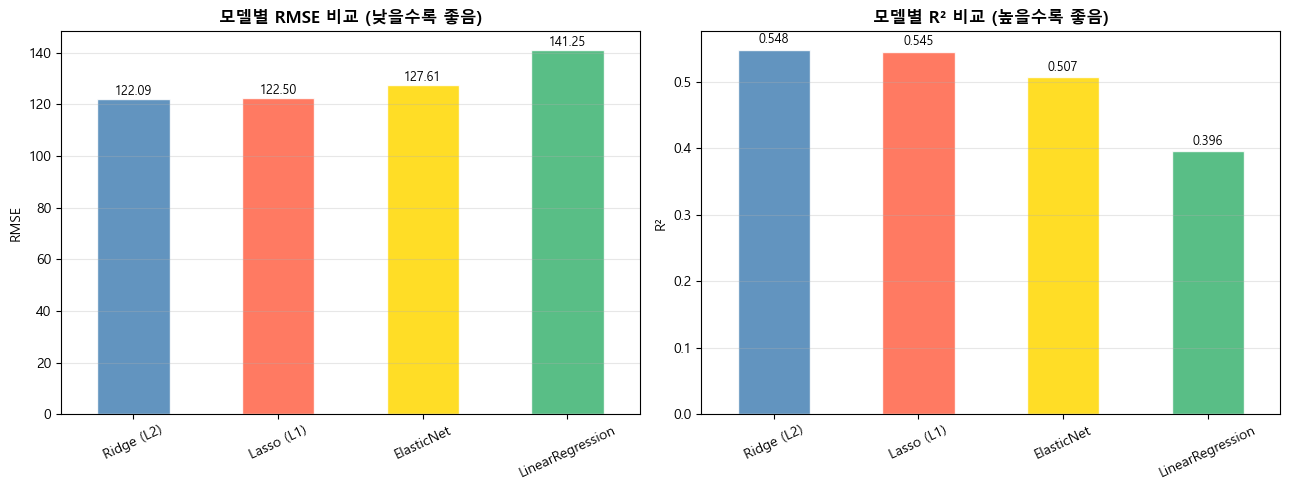

In [39]:
# 전체 모델 성능 비교
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac 한글
matplotlib.rcParams['axes.unicode_minus'] = False

summary_df = pd.DataFrame(all_results).set_index('model')
summary_df = summary_df.sort_values('RMSE')

print('=== 전체 모델 성능 비교 (RMSE 오름차순) ===')
display(
    summary_df.style
    .highlight_min(subset=['MSE', 'RMSE'], axis=0, color='lightgreen')
    .highlight_max(subset=['R²'],          axis=0, color='lightgreen')
    .format({'MSE': '{:.4f}', 'RMSE': '{:.4f}', 'R²': '{:.4f}'})
)

best = summary_df['RMSE'].idxmin()
print(f'\n🏆 최저 RMSE 모델: {best}  (RMSE: {summary_df.loc[best, "RMSE"]:.4f})')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

summary_df['RMSE'].plot(kind='bar', ax=axes[0],
    color=['steelblue','tomato','gold','mediumseagreen'],
    edgecolor='white', alpha=0.85)
axes[0].set_title('모델별 RMSE 비교 (낮을수록 좋음)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.3)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=9)

summary_df['R²'].plot(kind='bar', ax=axes[1],
    color=['steelblue','tomato','gold','mediumseagreen'],
    edgecolor='white', alpha=0.85)
axes[1].set_title('모델별 R² 비교 (높을수록 좋음)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.3)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 선생님 Github

In [ ]:
https://www.kaggle.com/c/bike-sharing-demand/data?select=train.csv

# 데이터 수집

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rc('figure', figsize=(10, 6))

from matplotlib import rcParams
rcParams['font.family'] = 'New Gulim'
rcParams['font.size'] = 10
rcParams['axes.unicode_minus'] = False

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# log 값 변환 시 NaN등의 이슈로 log() 가 아닌 log1p() 를 이용하여 RMSLE 계산
def rmsle(y, pred):
    log_y = np.log1p(y)
    log_pred = np.log1p(pred)
    squared_error = (log_y - log_pred) ** 2
    rmsle = np.sqrt(np.mean(squared_error))
    return rmsle

# 사이킷런의 mean_squared_error() 를 이용하여 RMSE 계산
def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

# RMSLE, RMSE, MAE 를 모두 계산
def evaluate_regr(y, pred):
    rmsle_val = rmsle(y, pred)
    rmse_val  = rmse(y, pred)
    mae_val   = mean_absolute_error(y, pred)
    print('RMSLE: {:.3f}, RMSE: {:.3f}, MAE: {:.3f}'.format(rmsle_val, rmse_val, mae_val))

# 회귀 모델의 평가에서 R2 보다는 MAE 를 활용한다.

In [58]:
# 데이터 로딩
bike_df = pd.read_csv(r'C:\Users\Admin\hipython\data\bike_train.csv')
bike_df.head()
print(bike_df.shape)
bike_df.head()

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


# 데이터 탐색

In [59]:
import numpy as np
import pandas as pd

# 1단계) 데이터 구조 점검 (shape / head / columns / dtypes)

In [60]:
print(bike_df.columns.tolist())
print("shape:", bike_df.shape)
print(bike_df.dtypes)

['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
shape: (10886, 12)
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


In [61]:
# [STEP 2] 누수(leakage) 확인 + 결측치 점검
# 1) casual + registered = count 관계 확인 (대부분 동일하면 누수 확정)
leak_equal_cnt = ((bike_df["casual"] + bike_df["registered"]) == bike_df["count"]).sum()
total = len(bike_df)
print(f"leak check: (casual+registered)==count  -> {leak_equal_cnt}/{total} ({leak_equal_cnt/total:.4%})")

# 2) 결측치 확인
print("\n[missing values]")
print(bike_df.isnull().sum().sort_values(ascending=False).head(20))

leak check: (casual+registered)==count  -> 10886/10886 (100.0000%)

[missing values]
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


# datetime 변환 + 시간 파생 피처 생성

In [62]:
bike_step3 = bike_df.copy()

# 1) datetime 문자열 -> datetime 타입 변환
bike_step3["datetime"] = pd.to_datetime(bike_step3["datetime"])
bike_step3.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [63]:
# 2) 파생 피처 생성
bike_step3["year"] = bike_step3["datetime"].dt.year
bike_step3["month"] = bike_step3["datetime"].dt.month
bike_step3["day"] = bike_step3["datetime"].dt.day
bike_step3["hour"] = bike_step3["datetime"].dt.hour
bike_step3["dayofweek"] = bike_step3["datetime"].dt.dayofweek  # 월=0, 요일

In [64]:
bike_step3['workingday'].value_counts()

workingday
1    7412
0    3474
Name: count, dtype: int64

In [65]:
bike_step3['holiday'].value_counts()

holiday
0    10575
1      311
Name: count, dtype: int64

# 파생변수 추가 : 주말/출퇴근시간대 (선택)

In [66]:
# 주말/출퇴근 시간대
# bike_step3["is_weekend"] = (bike_step3["dayofweek"] >= 5).astype(int)
# bike_step3["rush_hour"] = bike_step3["hour"].isin([7, 8, 9, 17, 18, 19]).astype(int)

In [67]:
# 체감-실제 온도 차이
# bike_step3["temp_diff"] = bike_step3["atemp"] - bike_step3["temp"]

In [68]:
bike_step3.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5


# 학습용 데이터 구성(X/y) + 홀드아웃 분리

In [69]:
from sklearn.model_selection import train_test_split

bike_step4 = bike_step3.copy()

# 1) 누수 컬럼 및 원본 datetime 제거
drop_cols = ["datetime", "casual", "registered"]
X = bike_step4.drop(columns=["count"] + drop_cols)
y = bike_step4["count"].copy()

# 2) 홀드아웃 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

print("\n[train columns]")
print(X_train.columns.tolist())

X_train shape: (8708, 13)
X_valid shape: (2178, 13)
y_train shape: (8708,)
y_valid shape: (2178,)

[train columns]
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'dayofweek']


# 전처리(원-핫, 스케일러)

In [70]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 1) 컬럼 타입 구분
categorical_cols = ["season","holiday","workingday","weather","year","month","day","hour","dayofweek"]
numeric_cols = ["temp","atemp","humidity","windspeed"]

# 2) 전처리: 범주형 원핫 + 수치형 스케일
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop"
)